Import Libraries



In [95]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

Load data

In [96]:
df=pd.read_csv('StudentsPerformance.csv')

In [97]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [98]:
df.tail()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
995,female,group E,master's degree,standard,completed,88,99,95
996,male,group C,high school,free/reduced,none,62,55,55
997,female,group C,high school,free/reduced,completed,59,71,65
998,female,group D,some college,standard,completed,68,78,77
999,female,group D,some college,free/reduced,none,77,86,86


In [99]:
df.shape

(1000, 8)

In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [101]:
df.isnull().sum()

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64

Target Feature

In [102]:
df["FinalScore"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3


Encoding

In [103]:
df["gender"].unique()


array(['female', 'male'], dtype=object)

In [104]:
df["gender"] = df["gender"].map({
    "male": 0,
    "female": 1
})


In [105]:
df["race/ethnicity"].unique()

array(['group B', 'group C', 'group A', 'group D', 'group E'],
      dtype=object)

In [106]:
df = pd.get_dummies(df, columns=["race/ethnicity"], drop_first=True)


In [107]:
df["parental level of education"].unique()

array(["bachelor's degree", 'some college', "master's degree",
       "associate's degree", 'high school', 'some high school'],
      dtype=object)

In [108]:
education_map = {
    'some high school':0,
    "high school": 1,
    "some college": 2,
    "associate's degree": 3,
    "bachelor's degree": 4,
    "master's degree": 5
}

df["parental level of education"] = df["parental level of education"].map(education_map)


In [109]:
df["lunch"].unique()

array(['standard', 'free/reduced'], dtype=object)

In [110]:
df["lunch"] = df["lunch"].map({
    "free/reduced": 0,
    "standard": 1
})


In [111]:
df["test preparation course"].unique()

array(['none', 'completed'], dtype=object)

In [112]:
df["test preparation course"] = df["test preparation course"].map({
    "none": 0,
    "completed": 1
})


In [113]:
df.columns

Index(['gender', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score', 'FinalScore', 'race/ethnicity_group B',
       'race/ethnicity_group C', 'race/ethnicity_group D',
       'race/ethnicity_group E'],
      dtype='object')

Split

In [114]:
X = df.drop(columns=["math score", "reading score", "writing score", "FinalScore"])
y = df["FinalScore"]


In [115]:
print(X.dtypes)


gender                         int64
parental level of education    int64
lunch                          int64
test preparation course        int64
race/ethnicity_group B          bool
race/ethnicity_group C          bool
race/ethnicity_group D          bool
race/ethnicity_group E          bool
dtype: object


Correlation

In [131]:
# Compute correlation matrix
corr_matrix = pd.concat([X, y], axis=1).corr()

# Extract correlation with FinalScore
target_corr = corr_matrix["FinalScore"].drop("FinalScore")

# Sort by absolute correlation
target_corr = target_corr.sort_values(ascending=False)

print("Correlation with FinalScore:")
print(target_corr)


Correlation with FinalScore:
lunch                          0.290064
test preparation course        0.256710
parental level of education    0.205785
race/ethnicity_group E         0.141050
gender                         0.130861
race/ethnicity_group D         0.058902
race/ethnicity_group C        -0.030691
race/ethnicity_group B        -0.078247
Name: FinalScore, dtype: float64


In [117]:
selected_features = target_corr[target_corr > 0.11].index

print("Selected Features Based on Correlation:")
print(selected_features)


Selected Features Based on Correlation:
Index(['lunch', 'test preparation course', 'parental level of education',
       'race/ethnicity_group E', 'gender'],
      dtype='object')


In [124]:
X_selected = df[selected_features]
y = df["FinalScore"]


In [125]:
print(X_selected.dtypes)


lunch                          int64
test preparation course        int64
parental level of education    int64
race/ethnicity_group E          bool
gender                         int64
dtype: object


In [126]:
X_selected["race/ethnicity_group E"] = X_selected["race/ethnicity_group E"].astype(int)


C:\Users\jayas\AppData\Local\Temp\ipykernel_14552\2465638307.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_selected["race/ethnicity_group E"] = X_selected["race/ethnicity_group E"].astype(int)


In [127]:
print(X_selected.dtypes)


lunch                          int64
test preparation course        int64
parental level of education    int64
race/ethnicity_group E         int64
gender                         int64
dtype: object


Normalization

In [128]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Train
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

Prediction

In [129]:
y_pred = model.predict(X_test)

# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model Performance")
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Performance
MSE: 179.5683174346336
RMSE: 13.40031034844468
R2 Score: 0.16233058061774752


Coefficients

In [130]:
# Create coefficient DataFrame
coeff_df = pd.DataFrame(
    model.coef_,
    index=X_selected.columns,
    columns=["Coefficient"]
)

# Absolute importance
coeff_df["Abs_Coefficient"] = abs(coeff_df["Coefficient"])

# Sort by importance
coeff_df = coeff_df.sort_values("Abs_Coefficient", ascending=False)

print("Feature Importance:")
print(coeff_df)


Feature Importance:
                             Coefficient  Abs_Coefficient
lunch                           4.423038         4.423038
test preparation course         3.768212         3.768212
parental level of education     2.397949         2.397949
gender                          2.051102         2.051102
race/ethnicity_group E          1.598217         1.598217


Coefficient Visualization

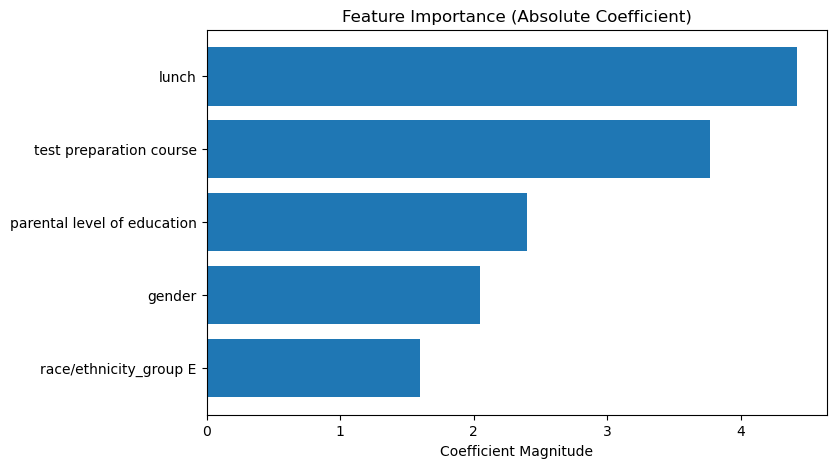

In [132]:
plt.figure(figsize=(8,5))
plt.barh(coeff_df.index, coeff_df["Abs_Coefficient"])
plt.xlabel("Coefficient Magnitude")
plt.title("Feature Importance (Absolute Coefficient)")
plt.gca().invert_yaxis()
plt.show()


Predicted vs Actual Plot

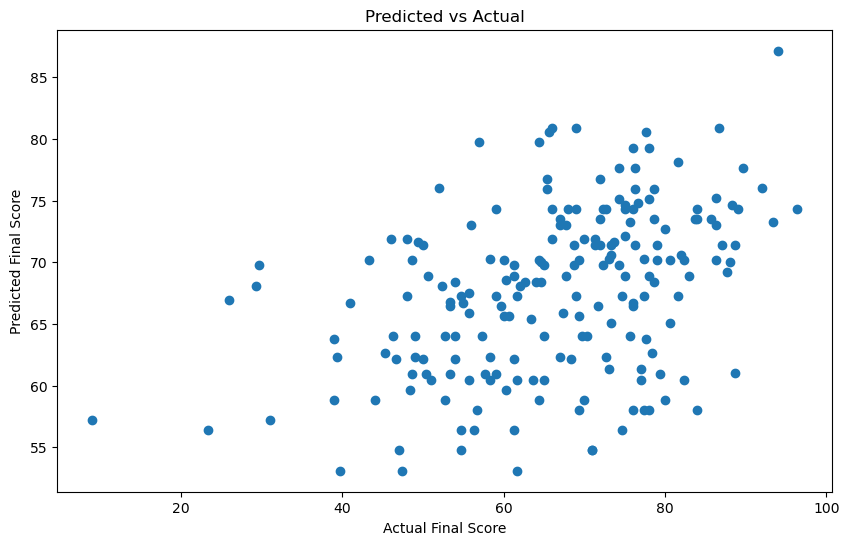

In [134]:
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Predicted vs Actual")
plt.show()


Residual Distribution Plot

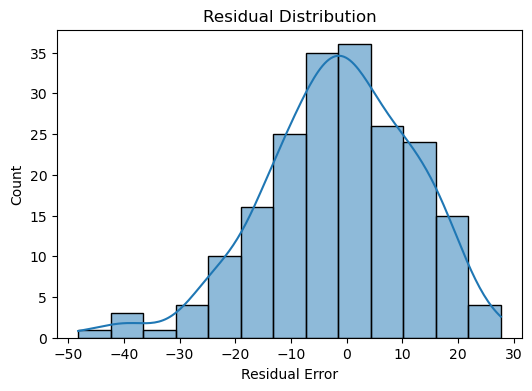

In [135]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.xlabel("Residual Error")
plt.show()


Ridge Regression

In [136]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)

print("\nRidge Regression Performance")
print("MSE:", mean_squared_error(y_test, y_pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_ridge)))
print("R2:", r2_score(y_test, y_pred_ridge))



Ridge Regression Performance
MSE: 179.55962242056842
RMSE: 13.399985911207834
R2: 0.1623711420457743


Lasso Regression

In [137]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)

print("\nLasso Regression Performance")
print("MSE:", mean_squared_error(y_test, y_pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lasso)))
print("R2:", r2_score(y_test, y_pred_lasso))



Lasso Regression Performance
MSE: 179.48482902844108
RMSE: 13.397194819380701
R2: 0.16272004623027625


Compare All Models

In [138]:
comparison = pd.DataFrame({
    "Model": ["Linear", "Ridge", "Lasso"],
    "R2 Score": [
        r2_score(y_test, y_pred),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_lasso)
    ]
})

comparison


,Model,R2 Score
0,Linear,0.162331
1,Ridge,0.162371
2,Lasso,0.162720
